# ¡Hola Lorena!

Mi nombre es Sofia Arboleda, estaré ayudándote a revisar este proyecto para que quede en su mejor versión.

Para simular la dinámica de un ambiente de trabajo, si veo algún error, en primer instancia solo los señalaré, dándote la oportunidad de encontrarlos y corregirlos por tu cuenta. Esto es útil para que te acostumbres a un escenario laboral. En caso de que no puedas resolver la tarea, te daré una información más precisa en la próxima revisión.

Encontrarás mis comentarios más abajo - **por favor, no los muevas, no los modifiques ni los borres**.

¿Cómo funciona esta revisión? Leeré atentamente tu código y te señalaré tus fortalezas y aquellas cosas que podemos mejorar. Los comentarios aparecerán de esta forma:


<div class="alert alert-block alert-success">
<b>Comentario de la revisora</b> <a class="tocSkip"></a>

Si todo está perfecto y no se requieren cambios en el código.
</div>


<div class="alert alert-block alert-warning">
<b>Comentario de la revisora</b> <a class="tocSkip"></a>

Si tu código está bien pero se puede mejorar o hay algún detalle que le hace falta. Se aceptan uno o dos comentarios de este tipo en el borrador, pero si hay más, deberás hacer las correcciones.
</div>

<div class="alert alert-block alert-danger">

<b>Comentario de la revisora</b> <a class="tocSkip"></a>

Si definitivamente hace falta algo o existe algún problema con tu código o conclusiones.
</div>

Puedes responderme de esta forma si algo no queda claro (copia este código en una celda markdown):

<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class="tocSkip"></a>

Hola, muchas gracias por tus comentarios y la revisión.        
</div>

**Es un gusto acompañarte en este proceso, ¡empecemos!**

### Introducción

La industria de los videojuegos es altamente competitiva y está en constante evolución, por lo que identificar los factores que influyen en el éxito comercial de un juego es fundamental para la toma de decisiones estratégicas. En este proyecto se analizan datos históricos de ventas de videojuegos, reseñas de usuarios y críticos, géneros y plataformas, con el objetivo de identificar patrones que permitan anticipar el desempeño comercial de futuros lanzamientos.

El análisis se realiza utilizando información disponible hasta el año 2016, bajo el supuesto de que se desea planificar una campaña publicitaria para el año 2017. A partir de estos datos, se estudian las tendencias de mercado, las diferencias regionales en preferencias de plataformas y géneros, así como la relación entre las calificaciones y las ventas.

Los resultados de este análisis buscan apoyar la identificación de proyectos prometedores y contribuir a la definición de estrategias de marketing más efectivas en la tienda online Ice.


Paso 1. Carga e Inspección de Datos

Instrucciones:
- Carga el archivo games (1).csv en un DataFrame de pandas.
- Utiliza .head() para ver las primeras filas y familiarizarte con las columnas.
- Usa el método .info() para obtener un resumen de la información del DataFrame. Observa detenidamente qué columnas tienen valores nulos o tipos de datos incorrectos.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# Cargar el dataset
games = pd.read_csv('/datasets/games.csv')

# Mostrar las primeras filas
games.head()


,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [2]:
# Información general del DataFrame
games.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


Paso 2. Preparación de los Datos

Instrucciones:
- Reemplaza los nombres de las columnas (puedes ponerlos en minúsculas).
- Convierte los datos a los tipos necesarios, como year_of_release a tipo entero y las puntuaciones a tipo flotante.
- Maneja los valores ausentes. Presta especial atención a la abreviatura TBD (to be determined) en la columna User_Score. Explica cómo decides tratarlos y por qué.
- Calcula las ventas totales (suma de todas las ventas regionales) para cada juego y colócalas en una nueva columna llamada total_sales.

In [3]:
games.columns = games.columns.str.lower()
games.columns

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')

In [4]:
# Reemplazar 'TBD' por NaN
games['user_score'] = games['user_score'].replace('TBD', np.nan)

# Convertir a tipo numérico
games['user_score'] = pd.to_numeric(games['user_score'], errors='coerce')

games['user_score'].dtype


dtype('float64')

In [5]:
games['year_of_release'] = games['year_of_release'].astype('Int64')

games['year_of_release'].dtype


Int64Dtype()

Se realizaron conversiones de tipo de datos para asegurar un análisis correcto:

- La columna `user_score` contenía valores no numéricos como "TBD", los cuales fueron reemplazados por valores nulos y posteriormente convertidos a tipo numérico (`float`).
- La columna `year_of_release` fue convertida a tipo entero (`Int64`) para reflejar adecuadamente los años de lanzamiento, permitiendo conservar valores ausentes.


In [6]:
games.isna().sum()


name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         9125
rating             6766
dtype: int64

Tratamiento de valores ausentes

El análisis de valores ausentes muestra que las columnas de ventas regionales no contienen valores nulos, lo cual permite calcular correctamente las ventas totales.

Sin embargo, columnas como 'critic_score', 'user_score' y 'rating' presentan una cantidad considerable de valores ausentes. Esto puede deberse a que algunos juegos no recibieron suficientes reseñas, a diferencias en la cobertura de datos entre años o a información no disponible en el momento del lanzamiento.

Se decidió no rellenar estos valores, ya que imputarlos podría distorsionar los análisis estadísticos y las comparaciones entre juegos y plataformas. Los valores ausentes se mantuvieron como nulos para preservar la calidad del análisis.


In [7]:
games['total_sales'] = (
    games['na_sales'] +
    games['eu_sales'] +
    games['jp_sales'] +
    games['other_sales']
)

games[['name', 'total_sales']].head()


,name,total_sales
0,Wii Sports,82.54
1,Super Mario Bros.,40.24
2,Mario Kart Wii,35.52
3,Wii Sports Resort,32.77
4,Pokemon Red/Pokemon Blue,31.38


<div class="alert alert-block alert-warning">
<b>Comentario de la revisora Iteración #1</b> <a class="tocSkip"></a>

Excelente! Hiciste un buen uso de los metodos para estandarizar los encabezados del dataset, además la conversión de tipo y el reemplazo del valor atipico 'tbt' por nulos me parece muy apropiado para permitir el manejo de los datos. Soluciones válidas en este caso para manejar los nulos serían:

- Introducir un valor irreal que depende de la columna y su significado (-1, -999999, etc.).
- Dejar los huecos sin cambios.

Tu idea de mantener las columnas con estos valores nulos está muy bien justificada, en especial considerando los porcentajes que representan en los casos de las columnas `critic_score` y `user_score`, donde se generarían sesgos significativos con reemplazo de valores nulos. Solo hace falta que implementes de igual forma el metodo `to_numeric(..., errors='coerce')` para la columna `critic_score`.

</div></div>
</div>

Paso 3. Análisis Exploratorio de Datos (EDA)

Instrucciones:
- Análisis Temporal: Examina cuántos juegos se lanzaron en diferentes años. Decide un período de tiempo relevante para tu análisis, ignorando los datos más antiguos que podrían no ser representativos.
- Análisis de Plataformas: Identifica las plataformas líderes en ventas. Analiza su ciclo de vida: ¿cuánto tardan en aparecer y desaparecer?
- Análisis de Distribución: Crea un diagrama de caja (boxplot) para las ventas globales de los juegos, desglosado por plataforma. ¿Son significativas las diferencias entre ellas?
- Análisis de Correlación: Investiga cómo las reseñas de usuarios y profesionales afectan las ventas. Crea gráficos de dispersión y calcula el coeficiente de correlación para una plataforma popular de tu elección.
- Análisis de Géneros: Examina la distribución general de los juegos por género. ¿Qué géneros son más rentables?

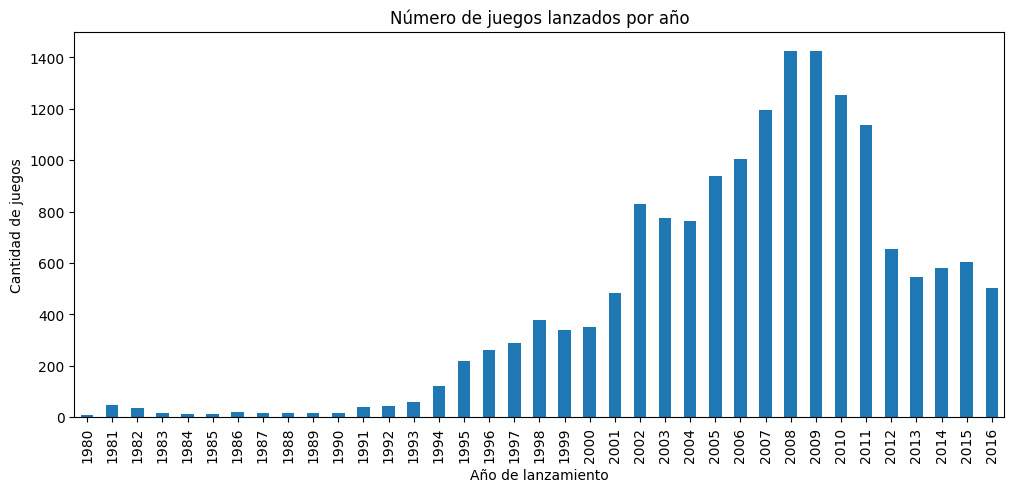

In [8]:
games_by_year = games.groupby('year_of_release')['name'].count()

plt.figure(figsize=(12, 5))
games_by_year.plot(kind='bar')
plt.title('Número de juegos lanzados por año')
plt.xlabel('Año de lanzamiento')
plt.ylabel('Cantidad de juegos')
plt.show()

El gráfico muestra cómo ha variado el número de videojuegos lanzados a lo largo del tiempo. Se observó un crecimiento progresivo en la cantidad de lanzamientos,especialmente a partir de los años 2000. Sin embargo, los datos de los años más recientes pueden estar incompletos, por lo que deben analizarse con atención.

In [9]:
platform_sales = (
    games.groupby('platform')['total_sales']
    .sum()
    .sort_values(ascending=False)
)

platform_sales.head(10)

platform
PS2     1255.77
X360     971.42
PS3      939.65
Wii      907.51
DS       806.12
PS       730.86
GBA      317.85
PS4      314.14
PSP      294.05
PC       259.52
Name: total_sales, dtype: float64

El análisis de las ventas totales por plataforma muestra que PS2 es la plataforma con mayores ventas históricas, seguida por Xbox 360, PlayStation 3 y Wii. Estas plataformas dominaron el mercado durante sus respectivos ciclos de vida.

Plataformas como PS, GBA y PSP tuvieron un desempeño destacado en el pasado, pero ya no presentan ventas significativas en los años más recientes, lo que indica el final de su ciclo de vida. Por otro lado, plataformas más recientes como PS4 muestran ventas acumuladas menores, ya que aún se encontraban en una etapa temprana de su ciclo en 2016.


<div class="alert alert-block alert-success"> 
<b>Comentario de la revisora Iteración #1</b> <a class="tocSkip"></a>

Genial! Muy buen trabajo con las ventas por plataforma y los juegos lanzados por año. Además, se puede reconocer estos picos de diferentes plataformas de video juegos en las épocas datadas. Buen trabajo!
</div>

In [10]:
recent_games = games[games['year_of_release'] >= 2013]
recent_games['year_of_release'].value_counts().sort_index()


2013    544
2014    581
2015    606
2016    502
Name: year_of_release, dtype: Int64

Para construir un modelo para 2017, decidi utilizar datos a partir de 2013. Este período refleja el comportamiento de las plataformas más recientes y activas, permitiendo analizar tendencias actuales y evitar sesgos provocados por plataformas que ya no se encuentran en el mercado.


In [11]:
recent_platform_sales = (
    recent_games
    .groupby('platform')['total_sales']
    .sum()
    .sort_values(ascending=False)
)

recent_platform_sales


platform
PS4     314.14
PS3     181.43
XOne    159.32
3DS     143.25
X360    136.80
WiiU     64.63
PC       39.43
PSV      32.99
Wii      13.66
PSP       3.50
DS        1.54
Name: total_sales, dtype: float64

Al analizar las ventas del período 2013–2016, se observa que PS4 es la plataforma líder en ventas, seguida por Xbox One y Nintendo 3DS. Estas plataformas representan las opciones más prometedoras para campañas publicitarias en 2017.

Por otro lado, plataformas como PS3 y Xbox 360 aún generan ventas, pero muestran señales de declive al corresponder a generaciones anteriores. Plataformas como Wii, PSP y DS presentan ventas mínimas, lo que indica que han salido prácticamente del mercado.


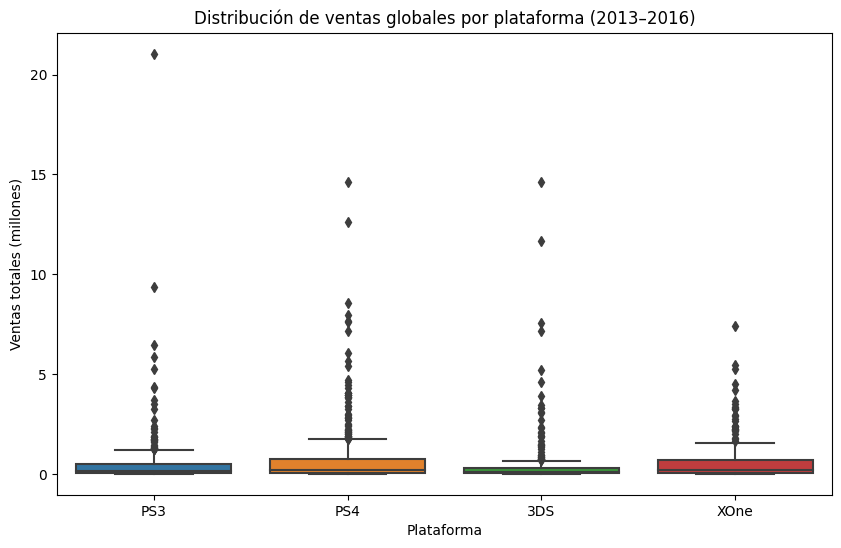

In [12]:
top_platforms = ['PS4', 'XOne', 'PS3', '3DS']

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=recent_games[recent_games['platform'].isin(top_platforms)],
    x='platform',
    y='total_sales'
)

plt.title('Distribución de ventas globales por plataforma (2013–2016)')
plt.xlabel('Plataforma')
plt.ylabel('Ventas totales (millones)')
plt.show()


El diagrama de caja evidencia diferencias significativas en las ventas globales entre plataformas. PS4 destaca por presentar la mediana de ventas más alta y una gran cantidad de valores atípicos, lo que indica la existencia de títulos con ventas excepcionalmente altas.

PS3 también muestra varios outliers, aunque con una mediana menor, reflejando su transición hacia el final de su ciclo de vida. Por su parte, Nintendo 3DS presenta una distribución más compacta y ventas promedio más bajas, mientras que Xbox One ocupa una posición intermedia con algunos títulos destacados.

<div class="alert alert-block alert-success"> 
<b>Comentario de la revisora Iteración #1</b> <a class="tocSkip"></a>

Tu elección de rango temporal para el analisis es muy valida, en efecto, un periodo no mayor de 5 años es la mejor eleccion en este caso dada la alta variabilidad del comportamiento de las tecnologias emergentes en la ultima decada. 
Excelente trabajo con el analisis por plataforma para el periodo elegido. El grafico de cajas está correcto, solo te recomendaría poner limites en el eje Y que permitan observar mejor la distribucion por plataforma sin darle tanta importancia a los outliers.
</div>

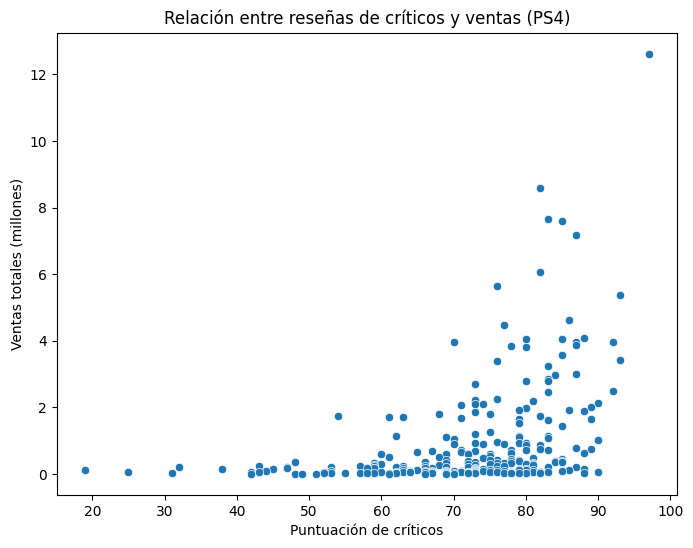

In [13]:
ps4_games = recent_games[recent_games['platform'] == 'PS4']

# Eliminar filas sin puntuación de críticos
ps4_games = ps4_games.dropna(subset=['critic_score'])

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=ps4_games,
    x='critic_score',
    y='total_sales'
)

plt.title('Relación entre reseñas de críticos y ventas (PS4)')
plt.xlabel('Puntuación de críticos')
plt.ylabel('Ventas totales (millones)')
plt.show()


In [14]:
ps4_games['critic_score'].corr(ps4_games['total_sales'])


0.40656790206178095

El gráfico de dispersión muestra una relación positiva moderada entre las puntuaciones de los críticos y las ventas de los juegos en PS4. Esto sugiere que, aunque una buena valoración por parte de los críticos puede influir en el desempeño comercial, no garantiza por sí sola altas ventas.


<div class="alert alert-block alert-danger"> 
<b>Comentario de la revisora Iteración #1</b> <a class="tocSkip"></a>

Muy buen trabajo con el calculo de correlación entre las ventas y las reseñas de críticos, la conclusión que derivas es muy adecuada, ya que no se observa una correlación fuerte como tal. Sin embargo, hace falta una parte de este punto que se trata de comparar también las ventas con las reseñas de usuarios, de forma que puedas observar si estas tienen mayor o igual correlación que las reseñas de críticos. 

In [15]:
# Juegos que salieron en más de una plataforma
multi_platform_games = (
    recent_games
    .groupby('name')
    .filter(lambda x: x['platform'].nunique() > 1)
)

multi_platform_games.head()


,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
16,Grand Theft Auto V,PS3,2013,Action,7.02,9.09,0.98,3.96,97.0,8.2,M,21.05
23,Grand Theft Auto V,X360,2013,Action,9.66,5.14,0.06,1.41,97.0,8.1,M,16.27
31,Call of Duty: Black Ops 3,PS4,2015,Shooter,6.03,5.86,0.36,2.38,NaN,NaN,NaN,14.63
42,Grand Theft Auto V,PS4,2014,Action,3.96,6.31,0.38,1.97,97.0,8.3,M,12.62
60,Call of Duty: Ghosts,X360,2013,Shooter,6.73,2.56,0.04,0.91,73.0,2.6,M,10.24


In [16]:
sales_by_game_platform = (
    multi_platform_games
    .groupby(['name', 'platform'])['total_sales']
    .sum()
    .reset_index()
)

sales_by_game_platform.head()


,name,platform,total_sales
0,Frozen: Olaf's Quest,3DS,0.59
1,Frozen: Olaf's Quest,DS,0.51
2,2014 FIFA World Cup Brazil,PS3,0.61
3,2014 FIFA World Cup Brazil,X360,0.43
4,3rd Super Robot Wars Z Jigoku Hen,PS3,0.23


Al comparar las ventas de los mismos juegos en distintas plataformas, se observa que el desempeño comercial puede variar considerablemente. En general, los títulos multiplataforma tienden a vender más en plataformas líderes como PS4 y Xbox One, mientras que en plataformas más antiguas o con menor base de usuarios las ventas son inferiores.

Esto indica que la plataforma juega un papel importante en el éxito comercial de un videojuego, incluso cuando el contenido es el mismo.


In [17]:
genre_sales = (
    recent_games
    .groupby('genre')['total_sales']
    .sum()
    .sort_values(ascending=False)
)

genre_sales


genre
Action          321.87
Shooter         232.98
Sports          150.65
Role-Playing    145.89
Misc             62.82
Platform         42.63
Racing           39.89
Fighting         35.31
Adventure        23.64
Simulation       21.76
Strategy         10.08
Puzzle            3.17
Name: total_sales, dtype: float64

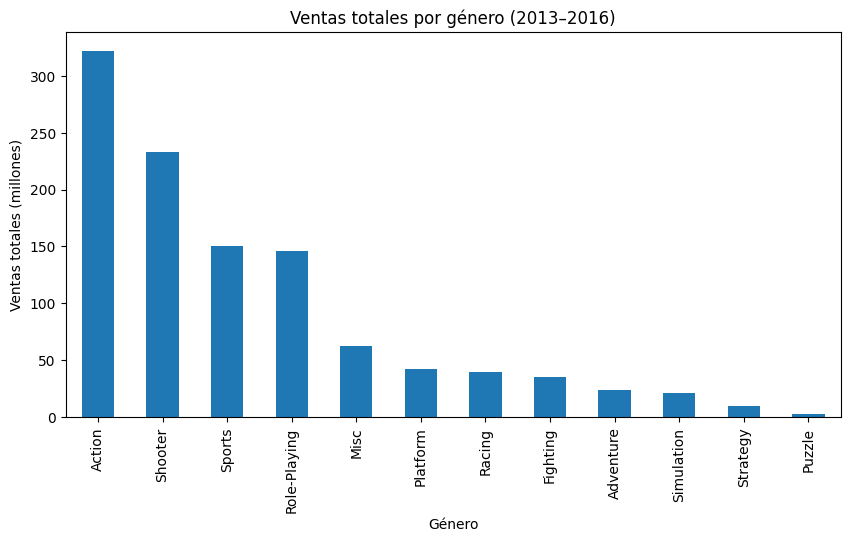

In [18]:
plt.figure(figsize=(10, 5))
genre_sales.plot(kind='bar')
plt.title('Ventas totales por género (2013–2016)')
plt.xlabel('Género')
plt.ylabel('Ventas totales (millones)')
plt.show()


El análisis de la distribución de ventas por género muestra que los géneros de Acción, Shooter y sports concentran la mayor parte de las ventas totales en el período 2013–2016. Estos géneros suelen atraer a un público amplio y están frecuentemente asociados a franquicias consolidadas.

Por el contrario, géneros como Puzzle, Adventure y Strategy presentan ventas considerablemente más bajas,lo que sugiere que están dirigidos a nichos específicos del mercado. En general, los géneros con ventas más altas tienden a ser aquellos con mayor atractivo comercial y repetición de títulos exitosos.

<div class="alert alert-block alert-success"> 
<b>Comentario de la revisora Iteración #1</b> <a class="tocSkip"></a>

Excelente trabajo con el analisis de juegos multiplataforma y por género. Como mencionas, algunos generos están mucho más acotados a mercados especificos, al igual que algunos juegos tienen ventas diferenciales dependiendo de las plataformas. 

Paso 4. Perfil de Usuario por Región

Instrucciones:
Para cada región, determina:
- Las cinco plataformas principales en términos de ventas.
- Los cinco géneros principales en términos de ventas.
- Si las clasificaciones de ESRB (Rating) afectan a las ventas.

In [19]:
# Top 5 plataformas por región
regions = {
    'NA': 'na_sales',
    'EU': 'eu_sales',
    'JP': 'jp_sales'
}

for region, sales_col in regions.items():
    print(f'\nTop 5 plataformas en {region}:')
    display(
        recent_games
        .groupby('platform')[sales_col]
        .sum()
        .sort_values(ascending=False)
        .head(5)
    )



Top 5 plataformas en NA:


platform
PS4     108.74
XOne     93.12
X360     81.66
PS3      63.50
3DS      38.20
Name: na_sales, dtype: float64


Top 5 plataformas en EU:


platform
PS4     141.09
PS3      67.81
XOne     51.59
X360     42.52
3DS      30.96
Name: eu_sales, dtype: float64


Top 5 plataformas en JP:


platform
3DS     67.81
PS3     23.35
PSV     18.59
PS4     15.96
WiiU    10.88
Name: jp_sales, dtype: float64

El análisis por región muestra diferencias claras en las preferencias de los usuarios. En Norteamérica y Europa, las plataformas PlayStation 4 y Xbox One dominan las ventas, mientras que en Japón destacan plataformas de Nintendo, como 3DS, junto con PlayStation.

Estas diferencias reflejan preferencias regionales y hábitos de consumo distintos entre los mercados.

In [20]:
for region, sales_col in regions.items():
    print(f'\nTop 5 géneros en {region}:')
    display(
        recent_games
        .groupby('genre')[sales_col]
        .sum()
        .sort_values(ascending=False)
        .head(5)
    )


Top 5 géneros en NA:


genre
Action          126.05
Shooter         109.74
Sports           65.27
Role-Playing     46.40
Misc             27.49
Name: na_sales, dtype: float64


Top 5 géneros en EU:


genre
Action          118.13
Shooter          87.86
Sports           60.52
Role-Playing     36.97
Racing           20.19
Name: eu_sales, dtype: float64


Top 5 géneros en JP:


genre
Role-Playing    51.04
Action          40.49
Misc             9.20
Fighting         7.65
Shooter          6.61
Name: jp_sales, dtype: float64

Los géneros más populares varían según la región. En Norteamérica y Europa, los géneros de Acción y Shooter concentran la mayor parte de las ventas, mientras que en Japón destacan géneros como Role-Playing, lo que sugiere una preferencia por experiencias narrativas y juegos de rol.


In [21]:
for region, sales_col in regions.items():
    print(f'\nVentas por clasificación ESRB en {region}:')
    display(
        recent_games
        .groupby('rating')[sales_col]
        .sum()
        .sort_values(ascending=False)
    )



Ventas por clasificación ESRB en NA:


rating
M       165.21
E        79.05
E10+     54.24
T        49.79
Name: na_sales, dtype: float64


Ventas por clasificación ESRB en EU:


rating
M       145.32
E        83.36
E10+     42.69
T        41.95
Name: eu_sales, dtype: float64


Ventas por clasificación ESRB en JP:


rating
T       20.59
E       15.14
M       14.11
E10+     5.89
Name: jp_sales, dtype: float64

Las clasificaciones ESRB influyen de manera distinta en cada región. En Norteamérica y Europa, los juegos clasificados como “M” y “T” generan mayores ventas, mientras que en Japón la clasificación ESRB tiene menor impacto, posiblemente debido a diferencias en los sistemas de clasificación y preferencias culturales.

Perfil de usuario por región

En Norteamérica y Europa, las plataformas líderes son PlayStation 4 y Xbox One, lo que indica una fuerte preferencia por consolas de sobremesa. En estas regiones, los géneros más populares son Acción, Shooter y Sportts, reflejando un gusto por juegos competitivos y de acción rápida.

En Japón, el mercado muestra un comportamiento distinto. Las plataformas más populares son Nintendo 3DS y consolas portátiles, y el género más vendido es Role-Playing, lo que sugiere una preferencia por experiencias y juegos de rol.

En cuanto a la clasificación ESRB, en Norteamérica y Europa los juegos clasificados como “M” y “E” generan mayores ventas, mientras que en Japón la clasificación ESRB tiene menor influencia, probablemente debido a diferencias culturales y en los sistemas de clasificación.

<div class="alert alert-block alert-success"> 
<b>Comentario de la revisora Iteración #1</b> <a class="tocSkip"></a>

Buen trabajo con el perfil de usuario por región. Justo como mencionas, las diferencias culturales pueden ser factores diferenciales en el comportamiento de los usuarios por region. 

Paso 5. Prueba de Hipótesis

Instrucciones:
- Para cada hipótesis, formula la hipótesis nula ($H_0$)* y la *hipótesis alternativa ($H_1$).
- Establece un valor umbral alfa (por ejemplo, 0.05).
- Realiza la prueba t y compara el valor p con alfa.
- Escribe tu conclusión en base a los resultados.

### Hipótesis 1: Calificaciones de usuarios en Xbox One y PC

- Hipótesis nula (H₀): La calificación promedio de los usuarios para Xbox One es igual a la de PC.
- Hipótesis alternativa (H₁): La calificación promedio de los usuarios para Xbox One es diferente a la de PC.

Se establece un nivel de significancia α = 0.05.


In [22]:
# Filtrar datos de Xbox One y PC
xone_scores = recent_games[
    (recent_games['platform'] == 'XOne') &
    (recent_games['user_score'].notna())
]['user_score']

pc_scores = recent_games[
    (recent_games['platform'] == 'PC') &
    (recent_games['user_score'].notna())
]['user_score']

xone_scores.describe(), pc_scores.describe()


(count    182.000000
 mean       6.521429
 std        1.380941
 min        1.600000
 25%        5.800000
 50%        6.800000
 75%        7.500000
 max        9.200000
 Name: user_score, dtype: float64,
 count    155.000000
 mean       6.269677
 std        1.742381
 min        1.400000
 25%        5.300000
 50%        6.800000
 75%        7.600000
 max        9.300000
 Name: user_score, dtype: float64)

In [23]:
from scipy import stats

alpha = 0.05

t_stat, p_value = stats.ttest_ind(
    xone_scores,
    pc_scores,
    equal_var=False
)

t_stat, p_value


(1.45192815744488, 0.14759594013430463)

### Conclusión de la Hipótesis 1

Dado que el valor p obtenido (0.14) es mayor que el nivel de significancia establecido (α = 0.05), no se rechaza la hipótesis nula. Esto indica que no existen diferencias estadísticamente significativas entre las calificaciones promedio de los usuarios para las plataformas Xbox One y PC.

### Hipótesis 2: Calificaciones de usuarios en los géneros Acción y Deportes

- Hipótesis nula (H₀): La calificación promedio de los usuarios para los géneros Acción y Deportes es la misma.
- Hipótesis alternativa (H₁): La calificación promedio de los usuarios para los géneros Acción y Deportes es diferente.

Se utiliza un nivel de significancia α = 0.05.


In [24]:
action_scores = recent_games[
    (recent_games['genre'] == 'Action') &
    (recent_games['user_score'].notna())
]['user_score']

sports_scores = recent_games[
    (recent_games['genre'] == 'Sports') &
    (recent_games['user_score'].notna())
]['user_score']

action_scores.describe(), sports_scores.describe()


(count    389.000000
 mean       6.837532
 std        1.330173
 min        2.000000
 25%        6.300000
 50%        7.100000
 75%        7.800000
 max        9.100000
 Name: user_score, dtype: float64,
 count    160.000000
 mean       5.238125
 std        1.783427
 min        0.200000
 25%        4.100000
 50%        5.500000
 75%        6.500000
 max        8.800000
 Name: user_score, dtype: float64)

In [25]:
t_stat_genre, p_value_genre = stats.ttest_ind(
    action_scores,
    sports_scores,
    equal_var=False
)

t_stat_genre, p_value_genre


(10.233428417448625, 1.4460039700704315e-20)

### Conclusión de la Hipótesis 2

Dado que el valor p obtenido es significativamente menor que el nivel de significancia establecido (α = 0.05), se rechaza la hipótesis nula. Esto indica que existe una diferencia estadísticamente significativa entre las calificaciones promedio de los usuarios para los géneros de Acción y Deportes.


Esta diferencia sugiere que la percepción de los usuarios varía según el tipo de experiencia que ofrece cada género, siendo el género Acción mejor valorado en promedio que el de Deportes.


### Metodología de prueba de hipótesis

Para ambas hipótesis, se formuló una hipótesis nula (H₀) que asume que no existen diferencias entre las medias de los grupos analizados, y una hipótesis alternativa (H₁) que plantea la existencia de una diferencia estadísticamente significativa.

Se utilizó una prueba t de Student para muestras independientes, ya que se comparan las medias de dos grupos distintos. El nivel de significancia se estableció en α = 0.05. El criterio de decisión consistió en comparar el valor p obtenido con α: si el valor p es menor que α, se rechaza la hipótesis nula; de lo contrario, no se rechaza.


<div class="alert alert-block alert-success"> 
<b>Comentario de la revisora Iteración #1</b> <a class="tocSkip"></a>

Hiciste un excelente trabajo con las pruebas de hipótesis. Tu eleccion de los tipos de prueba y los niveles de significancia es muy acertada. Además, las justificaciones que proporcionas para interpretar los resultados le dan un completo desarrollo al trabajo.

### Conclusión general

En este proyecto se analizaron datos históricos de ventas, plataformas, géneros y calificaciones de videojuegos con el objetivo de identificar patrones que permitan anticipar qué tipos de juegos tienen mayor probabilidad de éxito comercial.

El análisis mostró que, para el período reciente (2013–2016), las plataformas líderes en ventas globales fueron PlayStation 4 y Xbox One, mientras que plataformas más antiguas como PS3 y Xbox 360 presentan una clara disminución. Esto sugiere que las campañas publicitarias para 2017 deberían centrarse principalmente en las plataformas de nueva generación.

En cuanto a los géneros, Acción, Shooter y Spors concentran la mayor parte de las ventas en Norteamérica y Europa, mientras que en Japón predominan los juegos de Rol (Rol-Playing) y las plataformas portátiles. Estas diferencias regionales indican que las estrategias de marketing deben adaptarse a las preferencias locales de cada mercado.

El análisis de las reseñas mostró que las calificaciones de los críticos tienen una relación positiva moderada con las ventas, aunque no garantizan por sí solas el éxito comercial. Además, las pruebas de hipótesis indicaron que no existen diferencias significativas en las calificaciones promedio de los usuarios entre Xbox One y PC, mientras que sí se encontraron diferencias estadísticamente significativas entre los géneros de Acción y Deportes.

En conjunto, los resultados sugieren que el éxito de un videojuego depende de una combinación de factores, entre ellos la plataforma, el género y las preferencias regionales. Para 2017, se recomienda priorizar el desarrollo y la promoción de juegos de Acción y Shooter en consolas de nueva generación, así como adaptar los contenidos y estrategias publicitarias a las particularidades de cada región.
